# 4. Construcción de la red bipartita autor-video

Se parte de `data/comments_procesado.csv` y `data/videos_procesado.csv`. Como se estableció en la sección 1.4, solo 19 de los 293 videos del catálogo tienen comentarios en la muestra recolectada; en consecuencia, el conjunto de nodos-video de esta red son esos 19 videos, no los 293. Es una limitación de cobertura ya documentada, no una decisión de poda.

### 4.1 Definición de los conjuntos de nodos

- **Nodos de tipo `autor`**: un nodo por cada `author_channel_id` distinto que publicó al menos un comentario (332 nodos).
- **Nodos de tipo `video`**: un nodo por cada `video_id` que recibió al menos un comentario en la muestra (19 nodos).
- La red es **no dirigida**: la relación "comentó en" no tiene una direccionalidad semántica relevante entre autor y video para este análisis.

In [1]:
import json

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

comments = pd.read_csv('data/comments_procesado.csv', encoding='utf-8-sig')
videos = pd.read_csv('data/videos_procesado.csv', encoding='utf-8-sig')

autores_ids = comments['author_channel_id'].unique()
videos_ids = comments['video_id'].unique()

print(f'Nodos de tipo autor: {len(autores_ids)}')
print(f'Nodos de tipo video: {len(videos_ids)}')

Nodos de tipo autor: 332
Nodos de tipo video: 19


### 4.2 Definición de las aristas y su peso

In [2]:
# Arista autor-video cuando el autor comentó en ese video; el peso es el
# número de comentarios que ese autor publicó en ese video específico.
aristas = (
    comments.groupby(['author_channel_id', 'video_id'])
    .size()
    .reset_index(name='peso')
)

print(f'Aristas (pares autor-video distintos): {len(aristas)}')
print('Distribución del peso (nº de aristas por valor de peso):')
print(aristas['peso'].value_counts().sort_index())
aristas.sort_values('peso', ascending=False).head(5)

Aristas (pares autor-video distintos): 343
Distribución del peso (nº de aristas por valor de peso):
peso
1    303
2     28
3      7
4      1
5      2
6      2
Name: count, dtype: int64


,author_channel_id,video_id,peso
244,UCi2KiZq63sRq8Mfbcp-MelQ,OkXlHx0hx-8,6
331,UCyJhqmMbsvjpoarBBStA2kg,6W4u8sGEnGM,6
33,UC5H8ASmMC9WrURmzeB4ySog,n8iP75gIpmw,5
165,UCV3fr-YOixFKCZBbJP1-X4w,6W4u8sGEnGM,5
57,UC9vMq1YF-e7C-VO0SHkbUTA,n8iP75gIpmw,4


### 4.3 Tabla de nodos y tabla de aristas

In [3]:
# --- Tabla de nodos ---
autor_stats = comments.groupby('author_channel_id').agg(
    n_comentarios=('comment_id', 'count'),
    n_videos_distintos=('video_id', 'nunique'),
    autor_nombre=('author_name', 'first'),
).reset_index().rename(columns={'author_channel_id': 'id'})
autor_stats['tipo'] = 'autor'

video_stats = comments.groupby('video_id').agg(
    n_comentarios=('comment_id', 'count'),
    n_autores_distintos=('author_channel_id', 'nunique'),
).reset_index().rename(columns={'video_id': 'id'})
video_stats = video_stats.merge(
    videos[['video_id', 'title', 'channel_name', 'category', 'view_count']],
    left_on='id', right_on='video_id', how='left',
).drop(columns='video_id')
video_stats['tipo'] = 'video'

nodos = pd.concat([
    autor_stats[['id', 'tipo', 'autor_nombre', 'n_comentarios', 'n_videos_distintos']],
    video_stats[['id', 'tipo', 'title', 'channel_name', 'category', 'view_count', 'n_comentarios', 'n_autores_distintos']],
], ignore_index=True)

nodos.to_csv('data/red_nodos.csv', index=False, encoding='utf-8-sig')
aristas.rename(columns={'author_channel_id': 'origen', 'video_id': 'destino'}).to_csv(
    'data/red_aristas.csv', index=False, encoding='utf-8-sig')

print(f'Tabla de nodos: {len(nodos)} filas -> guardada en data/red_nodos.csv')
print(f'Tabla de aristas: {len(aristas)} filas -> guardada en data/red_aristas.csv')
nodos.head(5)

Tabla de nodos: 351 filas -> guardada en data/red_nodos.csv
Tabla de aristas: 343 filas -> guardada en data/red_aristas.csv


,id,tipo,autor_nombre,n_comentarios,n_videos_distintos,title,channel_name,category,view_count,n_autores_distintos
0,UC-HeUTT6_g-VoiWds2a4H-w,autor,@JorgeMunoz-gd9et,1,1.0,NaN,NaN,NaN,NaN,NaN
1,UC-Iul5tDYH_oiAMXQH-KaaQ,autor,@AlbertoMancilla-p9h,1,1.0,NaN,NaN,NaN,NaN,NaN
2,UC-QOpE7GOxlXcHZ8b7HbQKA,autor,@mariaalexander427,2,1.0,NaN,NaN,NaN,NaN,NaN
3,UC-fiZBS5Gp1eCJd9ucgWnCg,autor,@Tommii.10,1,1.0,NaN,NaN,NaN,NaN,NaN
4,UC-hfX8J5JPJ-dfuakzegMLA,autor,@normaleticiaorozcojuarez2418,1,1.0,NaN,NaN,NaN,NaN,NaN


In [4]:
aristas.head(5)

,author_channel_id,video_id,peso
0,UC-HeUTT6_g-VoiWds2a4H-w,6W4u8sGEnGM,1
1,UC-Iul5tDYH_oiAMXQH-KaaQ,6W4u8sGEnGM,1
2,UC-QOpE7GOxlXcHZ8b7HbQKA,OkXlHx0hx-8,2
3,UC-fiZBS5Gp1eCJd9ucgWnCg,j43HgwYFKfk,1
4,UC-hfX8J5JPJ-dfuakzegMLA,n8iP75gIpmw,1


La tabla de nodos distingue explícitamente `tipo` (`autor`/`video`) y conserva atributos propios de cada tipo (para autores: nombre visible y número de videos distintos comentados; para videos: título, canal, categoría y `view_count`). La tabla de aristas queda en formato `origen` (autor) – `destino` (video) – `peso`, lista para cargarse en cualquier herramienta de análisis de redes.

### 4.4 Construcción y visualización de la red completa

In [5]:
G = nx.Graph()
for _, row in nodos.iterrows():
    G.add_node(row['id'], tipo=row['tipo'])
for _, row in aristas.iterrows():
    G.add_edge(row['author_channel_id'], row['video_id'], weight=row['peso'])

print(f'Nodos en la red: {G.number_of_nodes()} (autores: {len(autores_ids)}, videos: {len(videos_ids)})')
print(f'Aristas en la red: {G.number_of_edges()}')
print(f'¿Es bipartita?: {nx.is_bipartite(G)}')

Nodos en la red: 351 (autores: 332, videos: 19)
Aristas en la red: 343
¿Es bipartita?: True


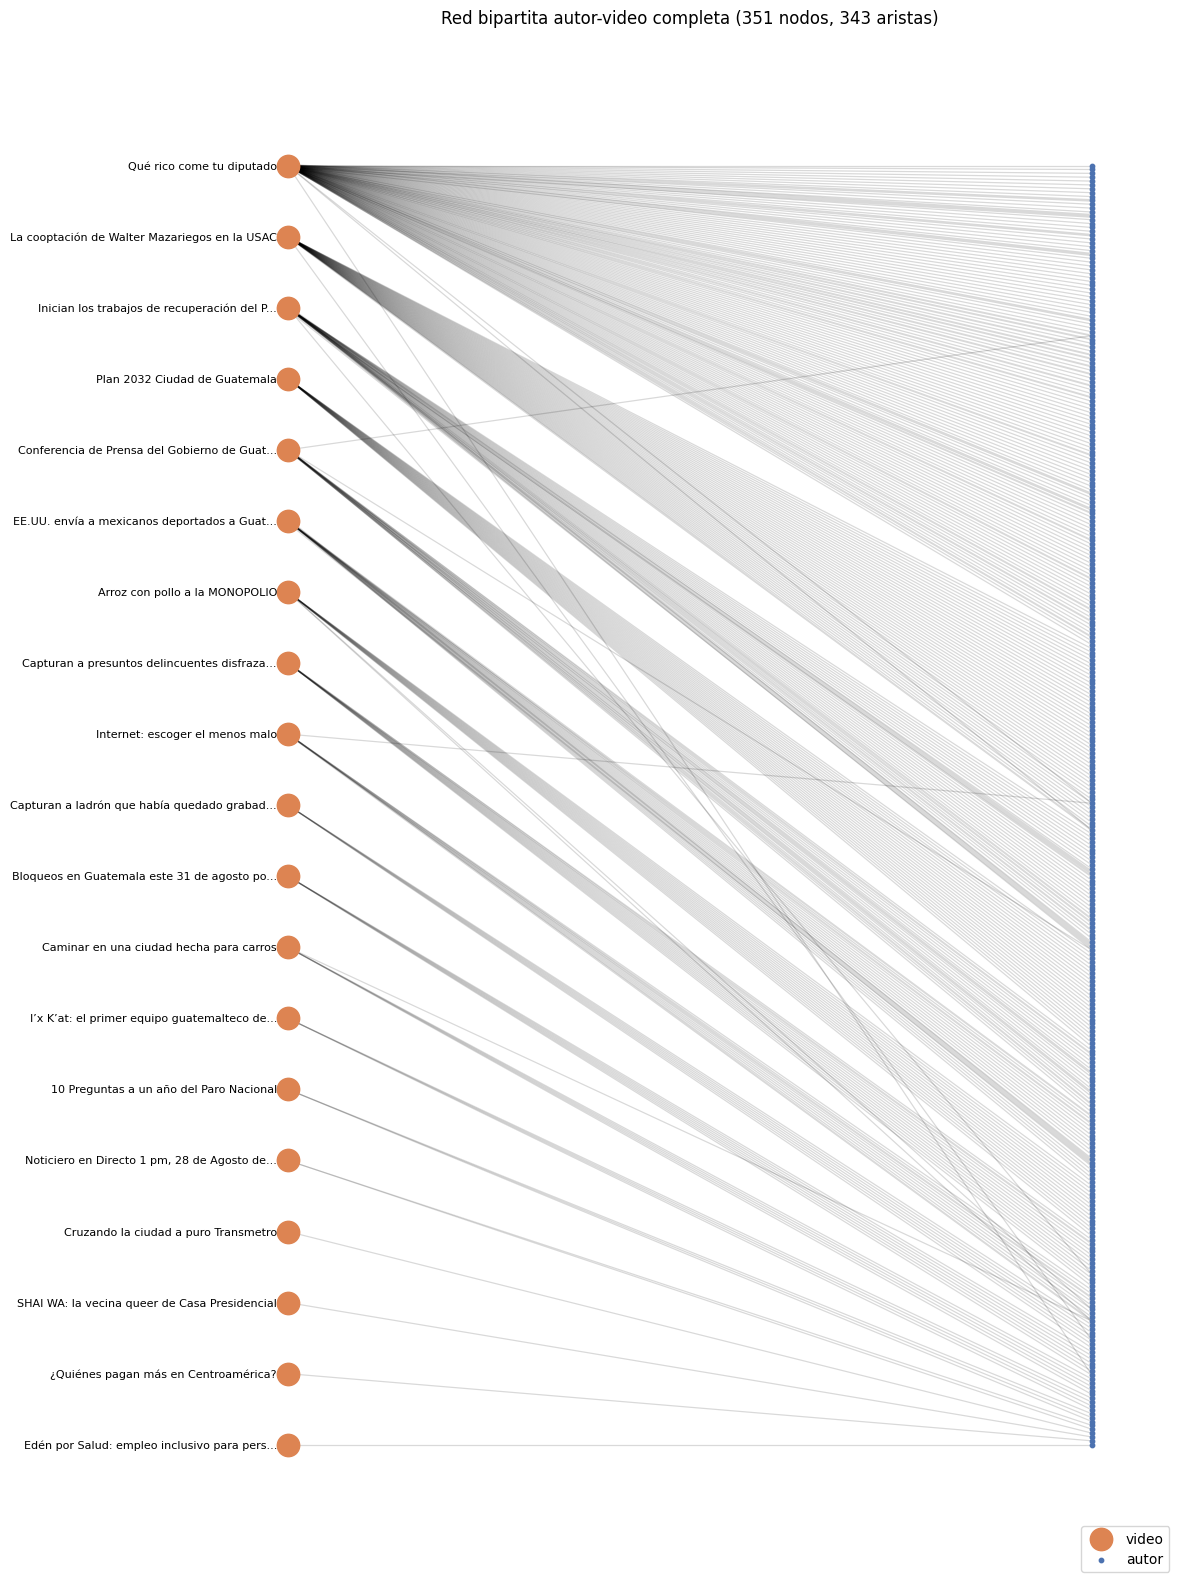

In [6]:
# Distribución en dos columnas (autor / video), pensada para que la red
# completa —los 351 nodos y las 343 aristas— sea visualmente legible: los
# videos se ordenan por número de comentarios y cada autor se ubica junto al
# video con el que tiene mayor peso, de modo que los "abanicos" por video
# queden agrupados y solo las aristas de autores puente los crucen. Ningún
# nodo ni arista se elimina del dibujo; esto es una elección de layout, no de
# poda de estructura.
orden_videos = comments.groupby('video_id').size().sort_values(ascending=False).index.tolist()
rango_video = {vid: i for i, vid in enumerate(orden_videos)}

autor_video_principal = {}
for autor in autores_ids:
    vecinos = sorted(G[autor].items(), key=lambda kv: (-kv[1]['weight'], kv[0]))
    autor_video_principal[autor] = vecinos[0][0]

orden_autores = sorted(autores_ids, key=lambda a: (rango_video[autor_video_principal[a]], a))

pos = {}
for i, vid in enumerate(orden_videos):
    pos[vid] = (0, -i)
alto = len(orden_videos) - 1
for i, a in enumerate(orden_autores):
    y = -(i / (len(orden_autores) - 1)) * alto
    pos[a] = (1, y)

fig, ax = plt.subplots(figsize=(12, 16))
pesos = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, alpha=0.15, width=[0.4 + 0.5 * w for w in pesos], ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=orden_videos, node_color='#DD8452', node_size=260, ax=ax, label='video')
nx.draw_networkx_nodes(G, pos, nodelist=orden_autores, node_color='#4C72B0', node_size=10, ax=ax, label='autor')

titulos = videos.set_index('video_id')['title'].to_dict()
for vid in orden_videos:
    etiqueta = titulos.get(vid, vid)
    etiqueta = etiqueta if len(etiqueta) <= 45 else etiqueta[:42] + '...'
    ax.annotate(etiqueta, pos[vid], xytext=(-8, 0), textcoords='offset points',
                ha='right', va='center', fontsize=8)

ax.legend(scatterpoints=1, loc='lower right')
ax.set_title(f'Red bipartita autor-video completa ({G.number_of_nodes()} nodos, {G.number_of_edges()} aristas)')
ax.axis('off')
plt.tight_layout()
plt.show()

La red completa muestra 19 "abanicos" claros, uno por video, dominados por autores que comentaron solo ahí (grosor de las aristas ∝ peso). Las pocas líneas que cruzan de un abanico a otro corresponden a los 9 autores que comentaron en más de un video (ya identificados en la sección 3.5) — son, visualmente, los únicos puntos de conexión entre videos distintos en toda la red.

### 4.5 Qué significa (y qué no significa) una arista

Una arista autor–video indica únicamente que ese `author_channel_id` publicó al menos un comentario principal en ese `video_id`; el peso es la cantidad de esos comentarios. Esto **no** implica que:

- el autor haya conversado con otros autores del mismo video (los datos no permiten identificar quién respondió a quién — la variable `reply_count` cuenta respuestas, no autores, según advierte el enunciado);
- exista aprobación, afinidad o alineación de opinión con el contenido del video (un comentario puede ser crítico, irónico o contradictorio);
- exista una relación entre autores que comparten un video (esa relación se construye explícitamente como una proyección aparte en el ejercicio 5, y sigue siendo co-participación, no interacción directa).

La arista describe co-presencia en un mismo espacio de comentarios, nada más.